In [1]:
import pandas as pd
import random

In [2]:
L = []

for i in range(10000):
    L.append(random.randint(1,6))

In [3]:
len(L)

10000

In [4]:
L[:5]

[1, 2, 2, 4, 3]

In [8]:
pd.Series(L).value_counts()

1    1706
2    1690
5    1684
3    1681
6    1627
4    1612
Name: count, dtype: int64

In [32]:
print(pd.Series(L).value_counts().sum())

pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()

10000


1    0.1706
2    0.1690
5    0.1684
3    0.1681
6    0.1627
4    0.1612
Name: count, dtype: float64

In [33]:
s = (pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()).sort_index()

In [34]:
s

1    0.1706
2    0.1690
3    0.1681
4    0.1612
5    0.1684
6    0.1627
Name: count, dtype: float64

<Axes: >

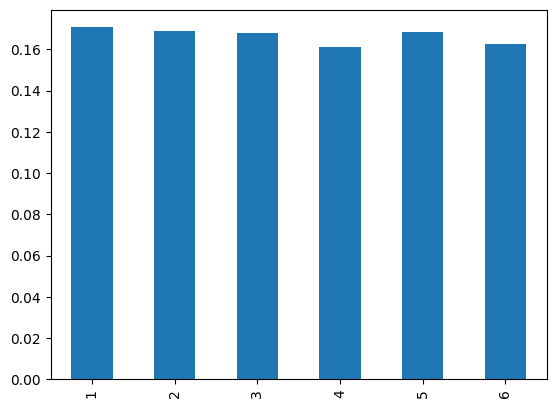

In [35]:
s.plot(kind='bar')

In [38]:
# 2 dice roll

L = []
for i in range(10000):
    a = random.randint(1,6)
    b = random.randint(1,6)
    L.append(a+b)

In [39]:
L[:5]

[4, 10, 9, 6, 5]

In [43]:
pd.Series(L).value_counts().sort_index()

2      296
3      545
4      912
5     1092
6     1446
7     1603
8     1322
9     1164
10     798
11     528
12     294
Name: count, dtype: int64

In [44]:
s = (pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()).sort_index()
s

2     0.0296
3     0.0545
4     0.0912
5     0.1092
6     0.1446
7     0.1603
8     0.1322
9     0.1164
10    0.0798
11    0.0528
12    0.0294
Name: count, dtype: float64

<Axes: >

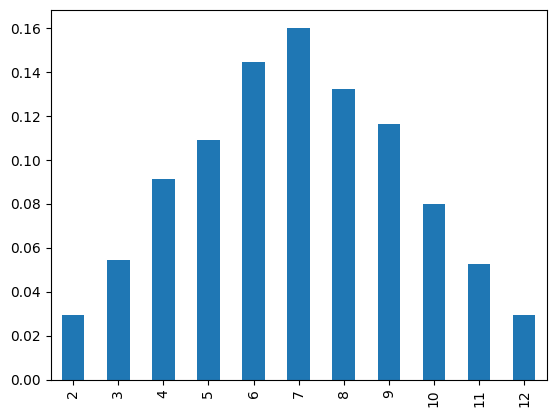

In [45]:
s.plot(kind='bar')

In [51]:
# s.plot(kind='pie')

In [48]:
import numpy as np
np.cumsum(s)

2     0.0296
3     0.0841
4     0.1753
5     0.2845
6     0.4291
7     0.5894
8     0.7216
9     0.8380
10    0.9178
11    0.9706
12    1.0000
Name: count, dtype: float64

<Axes: >

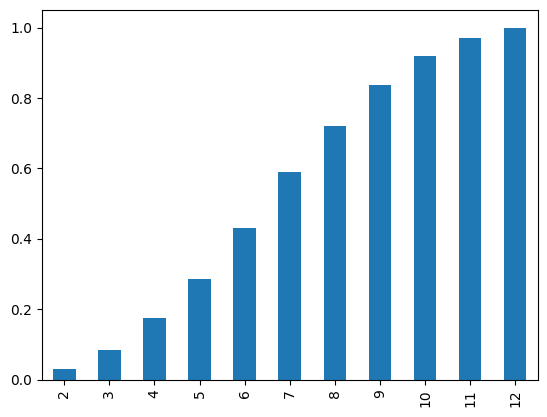

In [50]:
np.cumsum(s).plot(kind='bar')

### Parameteic Density Estimation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import normal

In [4]:
sample = normal(loc=50, scale=5, size=1000)
sample

array([45.44618727, 46.46825292, 45.87049877, 53.94339102, 47.67555145,
       42.60545906, 51.0865864 , 39.87947895, 54.26484961, 50.27642681,
       39.43189531, 51.03828965, 43.38350909, 57.62533367, 50.20770008,
       49.36173713, 44.60860569, 49.47467621, 45.92184973, 47.81039705,
       54.47059228, 53.21507092, 51.10605452, 46.63796369, 50.86647608,
       54.94593896, 44.5619134 , 52.76563274, 59.77362018, 55.76937039,
       54.83953038, 55.69463124, 51.96209442, 48.27216835, 49.13888227,
       52.84436978, 58.05245493, 51.6019525 , 42.9262601 , 53.22404687,
       48.35630905, 50.98446581, 48.65566585, 55.35527176, 48.032592  ,
       49.86038408, 51.03871875, 49.38514004, 51.85173902, 50.85227668,
       59.42030598, 48.27632792, 55.97535425, 52.89809823, 49.08385808,
       53.91085063, 43.56406626, 50.54260686, 51.35111703, 51.22858075,
       50.90519927, 51.01251889, 55.02053636, 45.23698872, 52.50823144,
       43.98498487, 52.23551614, 53.73739576, 52.90999828, 61.18

In [5]:
sample.mean()

np.float64(50.10997259440785)

In [6]:
sample.std()

np.float64(4.948032010725807)

(array([  6.,  23.,  86., 193., 243., 251., 137.,  52.,   6.,   3.]),
 array([34.00578969, 37.38499441, 40.76419914, 44.14340386, 47.52260859,
        50.90181332, 54.28101804, 57.66022277, 61.03942749, 64.41863222,
        67.79783694]),
 <BarContainer object of 10 artists>)

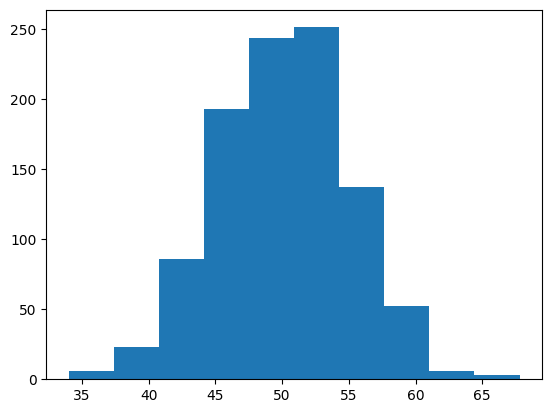

In [10]:
plt.hist(sample, bins=10)

In [11]:
sample_meam = sample.mean()
sample_std = sample.std()

In [38]:
# fit the distribution with the above parameter
from scipy.stats import norm
dist = norm(sample_meam, sample_std) # based on close to mean and std graph depends
dist

In [17]:
values = np.linspace(sample.min(), sample.max(), 100)

In [20]:
probabilities_density = [dist.pdf(value) for value in values]

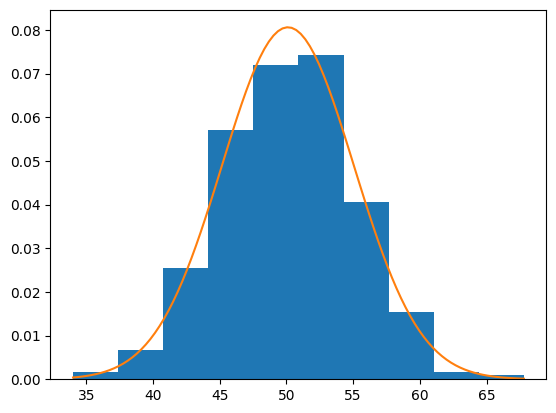

In [41]:
plt.hist(sample, bins=10, density=True)
plt.plot(values, probabilities_density)
# here the graph is depend on two things: mean and STD

C:\Temp\ipykernel_23540\1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

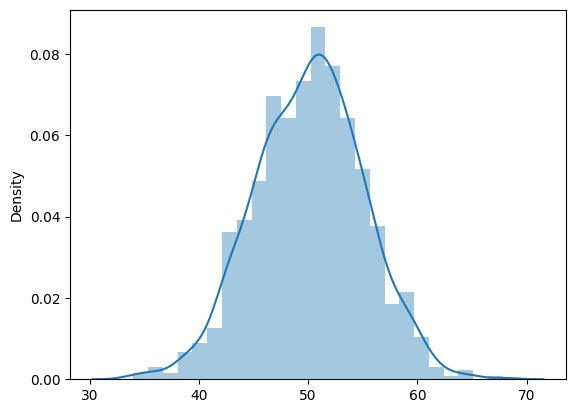

In [35]:
import seaborn as sns
sns.distplot(sample)

## KDE

In [42]:
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [43]:
sample

array([26.32596481, 19.64658893, 25.48463182, 15.68135213, 13.86794862,
       18.66902422, 16.85337628, 19.62064095, 22.83580445, 22.16419549,
       13.34619278, 13.92566971, 20.7019716 , 28.80423568, 19.84819226,
       15.38644313, 11.29413057, 16.89224225, 19.30688533, 21.65352114,
       18.74114083, 17.26197159, 24.37599153, 21.62158594, 15.08339787,
       30.25706844, 20.96521033, 33.34980131, 17.65691163, 16.19788409,
       15.2760508 , 19.40220854, 28.47650873, 23.2051125 , 22.30410304,
       23.96468579, 23.75536906, 23.74213135, 17.38928938, 22.9852057 ,
       23.68078855, 22.3368254 , 12.55343872, 19.43705965, 15.0553752 ,
       18.04474942, 22.70284189, 17.71845054, 19.03444079, 16.24140834,
        4.28178337, 17.91604166, 19.83111823, 21.11459681, 26.41549761,
       20.18242611, 28.39772116, 21.15732675, 14.48404367, 30.00354844,
       12.78553962, 19.08923898, 17.19758515, 15.45026671, 19.38061121,
       17.02677718, 17.88405361, 20.66091635, 31.30850913, 27.70

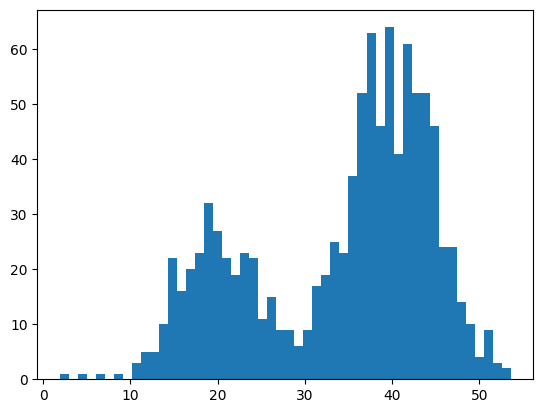

In [50]:
plt.hist(sample, bins=50)
plt.show()
# it is not follow any particular distribution

In [57]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=3, kernel='gaussian')

# convert data into 2D array
sample = sample.reshape((len(sample), 1))
sample
model.fit(sample)
# model fit means it find the Y values successfully

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",3
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None
Name,Type,Value
"bandwidth_ bandwidth_: floatValue of the bandwidth, given directly by the bandwidth parameter orestimated using the 'scott' or 'silverman' method... versionadded:: 1.0",int,3


In [58]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values), 1))

In [61]:
prob_density = model.score_samples(values)
prob_density = np.exp(prob_density)
prob_density

array([0.0002964 , 0.00033183, 0.00036869, 0.00040845, 0.00045359,
       0.0005078 , 0.00057612, 0.00066508, 0.0007827 , 0.00093843,
       0.00114291, 0.00140767, 0.00174455, 0.00216515, 0.00268001,
       0.00329785, 0.00402479, 0.00486352, 0.00581277, 0.00686684,
       0.00801543, 0.00924377, 0.01053296, 0.01186068, 0.01320192,
       0.01452996, 0.01581727, 0.01703641, 0.01816094, 0.01916621,
       0.02003021, 0.02073442, 0.02126458, 0.02161136, 0.02177093,
       0.02174512, 0.02154134, 0.02117216, 0.02065467, 0.02000972,
       0.01926119, 0.01843539, 0.01756056, 0.01666657, 0.01578464,
       0.0149471 , 0.01418696, 0.01353732, 0.01303062, 0.01269762,
       0.01256634, 0.01266102, 0.01300114, 0.01360075, 0.01446805,
       0.01560519, 0.01700821, 0.018667  , 0.02056501, 0.02267878,
       0.02497726, 0.02742129, 0.02996343, 0.03254867, 0.03511617,
       0.03760214, 0.03994348, 0.04208184, 0.04396712, 0.04556006,
       0.04683317, 0.04777005, 0.04836331, 0.04861174, 0.04851

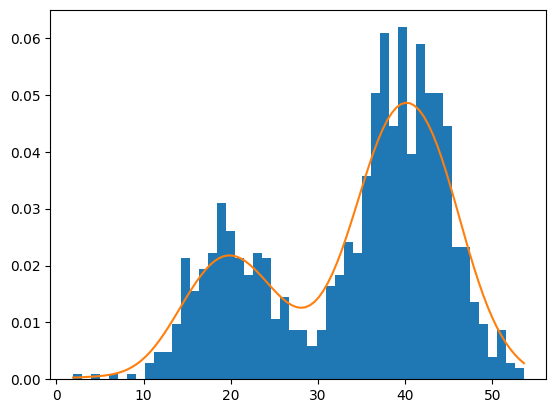

In [66]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], prob_density)
plt.show()

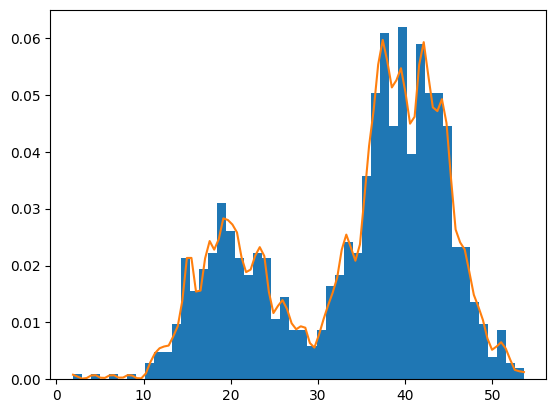

In [68]:
# if we decrease the bandwidth
model = KernelDensity(bandwidth=0.5, kernel='gaussian')
sample = sample.reshape((len(sample), 1))
model.fit(sample)

values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values), 1))

prob_density = model.score_samples(values)
prob_density = np.exp(prob_density)

plt.hist(sample, bins=50, density=True)
plt.plot(values[:], prob_density)
plt.show()

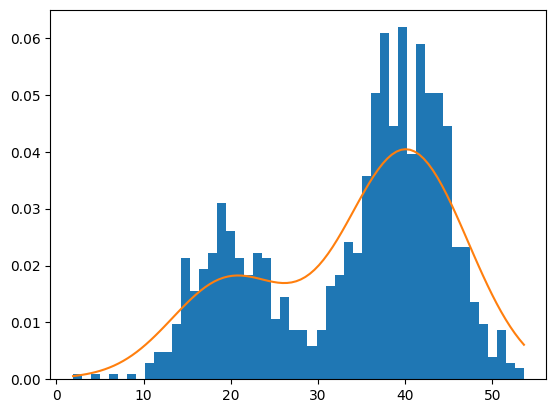

In [70]:
# if we increase the bandwidth
model = KernelDensity(bandwidth=5, kernel='gaussian')
sample = sample.reshape((len(sample), 1))
model.fit(sample)

values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values), 1))

prob_density = model.score_samples(values)
prob_density = np.exp(prob_density)

plt.hist(sample, bins=50, density=True)
plt.plot(values[:], prob_density)
plt.show()

<Axes: ylabel='Density'>

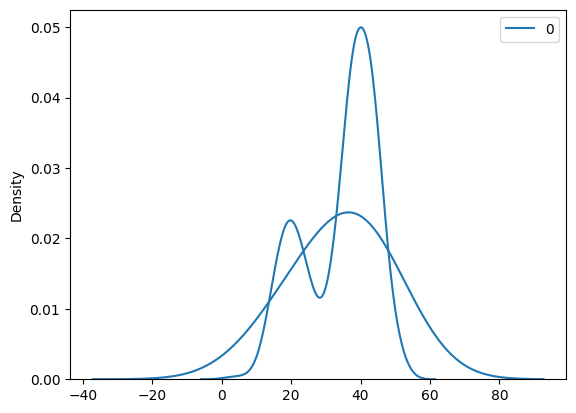

In [74]:
# same things we done using seaborn
sns.kdeplot(sample.reshape(len(sample), 1))
sns.kdeplot(sample.reshape(len(sample), 1), bw_adjust=5)
# sns.kdeplot(sample.reshape(len(sample), 1), bw_adjust=0.5)